In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

import threading
from concurrent.futures import ThreadPoolExecutor

ROOT = Path().resolve().parents[1]
sys.path.append(str(ROOT / "src"))

from forward import magcal
from forward.thread_func import thread_func

### Differential inversion
L1-L2 penalty

$$
P(\boldsymbol{\delta \beta}) =  \lambda_1 \left\| \boldsymbol{\delta \beta} \right\|_1 + \frac{\lambda_2}{2} \| \boldsymbol{\delta \beta} \|_2^2
$$

In [ ]:
# class for L1-L2 penalty inversion
from inversion.L1L2_penalty_inv import L1L2

In [5]:
# data misfit
def misfit(f, K, beta_star):
    return 0.5 * np.linalg.norm(f - K.dot(beta_star))**2

# penalty
def pen(beta, alpha):
    pen_1 = np.linalg.norm(beta, 1)
    pen_2 = 0.5 * np.linalg.norm(beta, 2)**2
    pen_all = alpha * pen_1 + (1. - alpha) * pen_2
    return pen_all

In [6]:
def calcCurvature2(x,y):
    
    dif_x = np.gradient(x)
    dif_y = np.gradient(y)
    dif2_x = np.gradient(dif_x)
    dif2_y = np.gradient(dif_y)
    
    curvature = np.abs(dif2_x * dif_y - dif_x * dif2_y) / (dif_x **2 + dif_y **2)**1.5
    return curvature

### Model domain

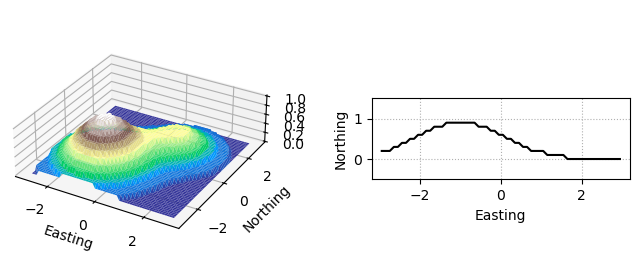

In [7]:
### Creation of subsurface grid: xgrd, ygrd, zgrd ###
# incx, incy, incz : grid spacing in the x, y, and z directions
incx = 0.1
incy = 0.1
incz = 0.1

x = np.arange(-3.0 + 0.5*incx, 3.0, incx)
y = np.arange(-3.0 + 0.5*incy, 3.0, incy)
nx = len(x)
ny = len(y)

# Two hills (northeast and southwest)
from scipy.ndimage import gaussian_filter

X, Y = np.meshgrid(x, y)

# Northeast hill
A1 = 0.5
x1, y1 = 1.0, 1.0
sigma1 = 1.25
z1 = A1 * np.exp(-((X - x1)**2 + (Y - y1)**2) / sigma1**2)

# Southwest hill
A2 = 1.0
x2, y2 = -1.0, -1.0
sigma2 = 1.5
z2 = A2 * np.exp(-((X - x2)**2 + (Y - y2)**2) / sigma2**2)

# Combined topography
T = z1 + z2

# Round to 0.1 increments
T = np.round(T / 0.1) * 0.1

### Creation of subsurface grid: xgrd, ygrd, zgrd ###
# Number of subsurface layers = 30  # 60×60×30
nz = 30
[yy2, zz2, xx2] = np.meshgrid(y, np.zeros(nz), x)

for k in range(nz):
    for i in range(nx):
        for j in range(ny):
            zz2[k, j, i] = T.reshape(-1)[i + nx*j] - incz / 2. - incz*k
            
xgrd = xx2.reshape(-1)
ygrd = yy2.reshape(-1)
zgrd = zz2.reshape(-1)

# For visualization
xfig, yfig, zfig = [], [], []

for i in range(len(xgrd)):
    j = i // (nx*ny)
    
    # Store coordinates of the 8 vertices of each grid cell
    xfig.append([xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, 
                 xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx])
    yfig.append([ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy, 
                 ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy])
    zfig.append([zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, 
                 zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz])

# Convert to arrays
xfig = np.array(xfig)
yfig = np.array(yfig)
zfig = np.array(zfig)

# dim: block size
dim = [[incx / 2., incx / 2.], [incy / 2., incy / 2.], [incz / 2., incz / 2.]]

# Near Tokyo
# Declination (degrees)
dec = -7.
# Inclination (degrees)
inc = 50.

# Visualization
fig = plt.figure(figsize = (8, 4))
plt.subplots_adjust(wspace=0.4, hspace=0.)

ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X, Y, T, rstride=1, cstride=1, cmap = plt.cm.terrain)
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_box_aspect((1,1,0.3))

ax = fig.add_subplot(122)
ys = 15
ax.plot(X[ys, :], T[ys,:], color = "black")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_aspect("equal")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-0.5, 1.5)
ax.grid(linestyle = "dotted")

Text(0.5, 1.0, 'NE–SW Cross-section (No Interpolation)')

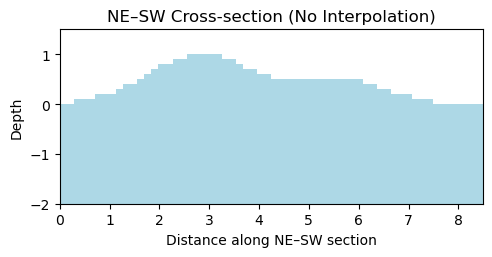

In [8]:
from matplotlib.patches import Rectangle

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(122)

tol = 0.05   # Section width (adjust as needed)

# Cross-section (NE–SW)
for i in range(len(xgrd)):

    # 8 vertices of the voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE–SW section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the section (southwest → northeast)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Draw rectangle (no interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

# Axis settings
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))  # Diagonal distance
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")
ax.set_xlabel("Distance along NE–SW section")
ax.set_ylabel("Depth")
ax.set_title("NE–SW Cross-section (No Interpolation)")

### Aeromagnetic survey layout（N-S direction, 100 m ASL）

CPU times: total: 22.5 s
Wall time: 35.1 s


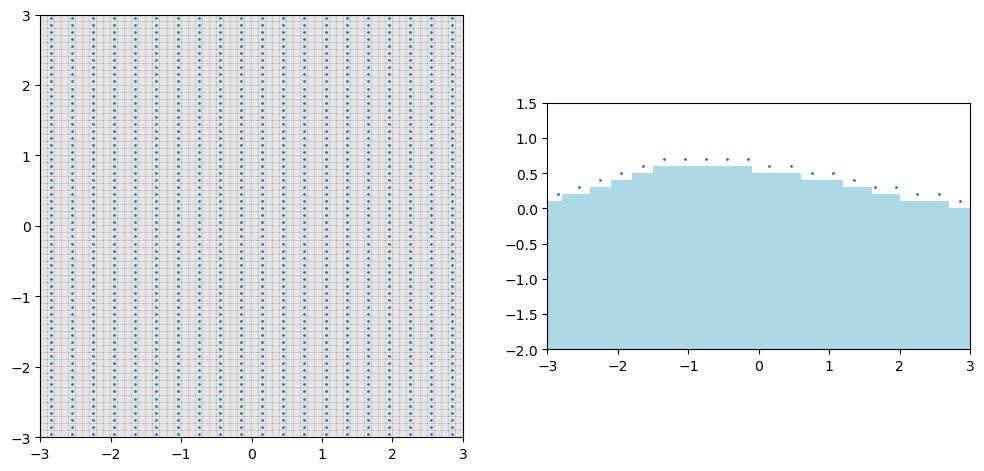

In [9]:
%%time
### Synthetic data generation ###
# Coordinates: x positive eastward, y positive northward, z positive upward

### Observation points: xobs, yobs, zobs ###
[xobs1, yobs1] = np.meshgrid(np.arange(-3.0 + incx + 0.5*incx, 3.0, 3*incx), np.arange(-3.0 + 0.5*incy, 3.0, incy))
xobs1 = xobs1.reshape(-1)
yobs1 = yobs1.reshape(-1)
zobs1 = np.zeros(len(xobs1))

for i in range(len(xobs1)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs1[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs1[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs1[i] = T.reshape(-1)[j] + 0.1 # 100 m above the surface

# Visualization
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs1, yobs1, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs1[(0<yobs1)&(yobs1<incy)], zobs1[(0<yobs1)&(yobs1<incy)], s = 1)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Width and height of the rectangular prism
        width  = x_max - x_min
        height = z_max - z_min

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### Aeromagnetic survey layout（E-W direction, 100 m ASL）

CPU times: total: 22.2 s
Wall time: 33.9 s


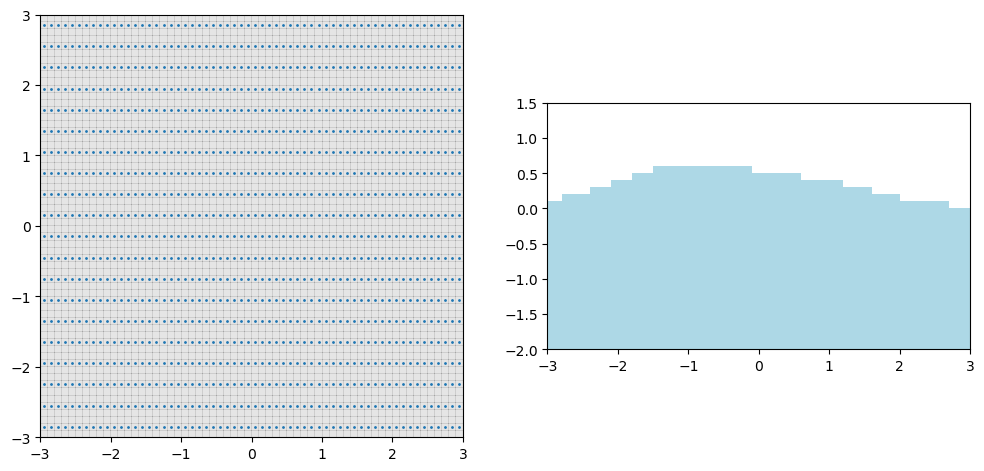

In [10]:
%%time
### Synthetic data generation ###
# Coordinates: x positive eastward, y positive northward, z positive upward

### Observation points: xobs, yobs, zobs ###
[xobs2, yobs2] = np.meshgrid(np.arange(-3.0 + 0.5*incx, 3.0, incx), np.arange(-3.0 + incx + 0.5*incy, 3.0, 3*incy))
xobs2 = xobs2.reshape(-1)
yobs2 = yobs2.reshape(-1)
zobs2 = np.zeros(len(xobs2))

for i in range(len(xobs2)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs2[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs2[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs2[i] = T.reshape(-1)[j] + 0.1 # 100 m above the surface

# Visualization
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs2, yobs2, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs2[(0<yobs2)&(yobs2<incy)], zobs2[(0<yobs2)&(yobs2<incy)], s = 1)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Width and height of the rectangular prism
        width  = x_max - x_min
        height = z_max - z_min

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### Aeromagnetic survey layout（N-S direction, 60 m ASL）

CPU times: total: 22.4 s
Wall time: 34.3 s


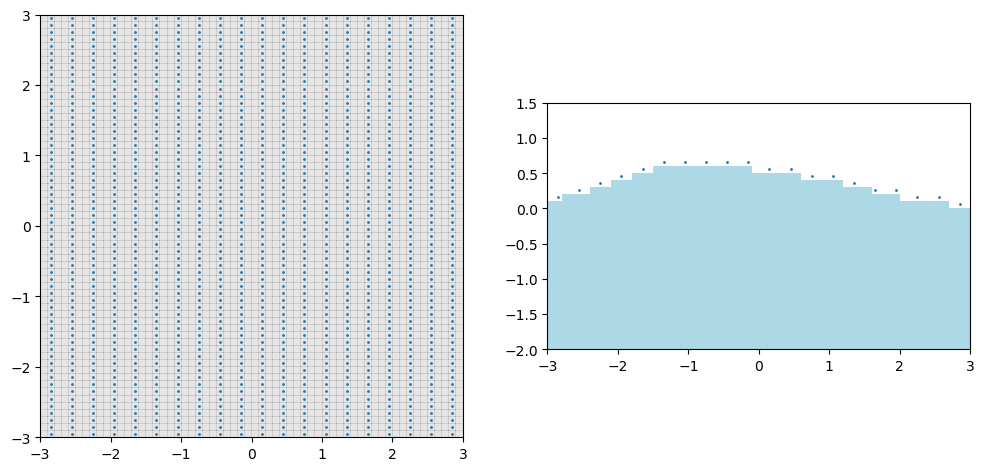

In [11]:
%%time
### Synthetic data generation ###
# Coordinates: x positive eastward, y positive northward, z positive upward

### Observation points: xobs, yobs, zobs ###
[xobs3, yobs3] = np.meshgrid(np.arange(-3.0 + incx + 0.5*incx, 3.0, 3*incx), np.arange(-3.0 + 0.5*incy, 3.0, incy))
xobs3 = xobs3.reshape(-1)
yobs3 = yobs3.reshape(-1)
zobs3 = np.zeros(len(xobs3))

for i in range(len(xobs3)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs3[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs3[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs3[i] = T.reshape(-1)[j] + 0.06 # 60 m above the surface

# Visualization
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs3, yobs3, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs3[(0<yobs3)&(yobs3<incy)], zobs3[(0<yobs3)&(yobs3<incy)], s = 1)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Width and height of the rectangular prism
        width  = x_max - x_min
        height = z_max - z_min

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### Aeromagnetic survey layout（E-W direction, 50 m ASL）

CPU times: total: 21.5 s
Wall time: 34.8 s


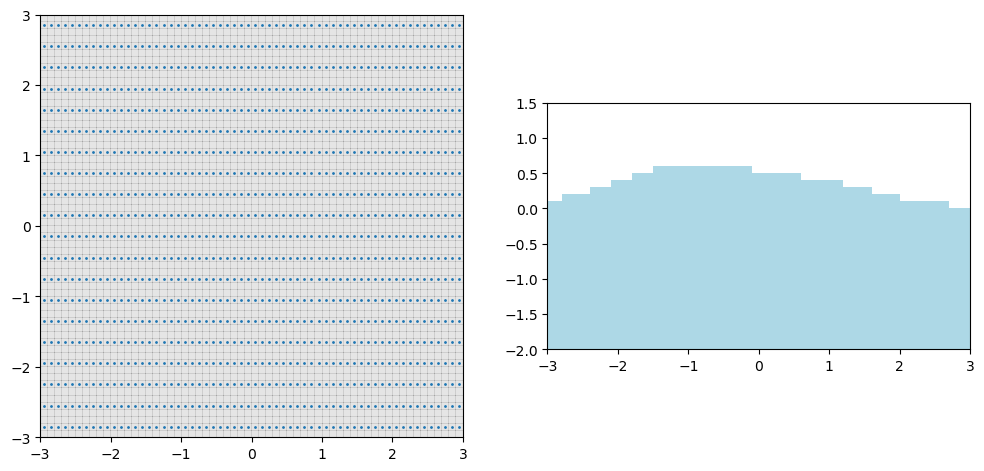

In [12]:
%%time
### Synthetic data generation ###
# Coordinates: x positive eastward, y positive northward, z positive upward

### Observation points: xobs, yobs, zobs ###
[xobs4, yobs4] = np.meshgrid(np.arange(-3.0 + 0.5*incx, 3.0, incx), np.arange(-3.0 + incx + 0.5*incy, 3.0, 3*incy))
xobs4 = xobs4.reshape(-1)
yobs4 = yobs4.reshape(-1)
zobs4 = np.zeros(len(xobs4))

for i in range(len(xobs4)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs4[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs4[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs4[i] = T.reshape(-1)[j] + 0.05 # 50 m above the surface

# Visualization
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs4, yobs4, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs4[(0<yobs4)&(yobs4<incy)], zobs4[(0<yobs4)&(yobs4<incy)], s = 1)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Width and height of the rectangular prism
        width  = x_max - x_min
        height = z_max - z_min

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### Kernel matrix

In [ ]:
%%time
# Compute the kernel matrix using parallel processing with threading
# Create unit vector
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# Number of threads (number of parallel workers)
n = 12

# Divide the computation range i = [0, nz] into n segments
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# Store return values from each thread in the ThreadPool
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs1, yobs1, zobs1, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# Retrieve results and stack them to construct the final kernel matrix
K1 = []
for res in results:
    Ki = res.result()
    if len(K1) == 0:
        K1 = Ki.copy()
    else:
        K1 = np.hstack((K1, Ki))

In [ ]:
%%time
# Compute the kernel matrix using parallel processing with threading
# Create unit vector
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# Number of threads (number of parallel workers)
n = 12

# Divide the computation range i = [0, nz] into n segments
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# Store return values from each thread in the ThreadPool
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs2, yobs2, zobs2, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# Retrieve results and stack them to construct the final kernel matrix
K2 = []
for res in results:
    Ki = res.result()
    if len(K2) == 0:
        K2 = Ki.copy()
    else:
        K2 = np.hstack((K2, Ki))

In [ ]:
%%time
# Compute the kernel matrix using parallel processing with threading
# Create unit vector
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# Number of threads (number of parallel workers)
n = 12

# Divide the computation range i = [0, nz] into n segments
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# Store return values from each thread in the ThreadPool
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs3, yobs3, zobs3, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# Retrieve results and stack them to construct the final kernel matrix
K3 = []
for res in results:
    Ki = res.result()
    if len(K3) == 0:
        K3 = Ki.copy()
    else:
        K3 = np.hstack((K3, Ki))

In [ ]:
%%time
# Compute the kernel matrix using parallel processing with threading
# Create unit vector
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# Number of threads (number of parallel workers)
n = 12

# Divide the computation range i = [0, nz] into n segments
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# Store return values from each thread in the ThreadPool
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs4, yobs4, zobs4, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# Retrieve results and stack them to construct the final kernel matrix
K4 = []
for res in results:
    Ki = res.result()
    if len(K4) == 0:
        K4 = Ki.copy()
    else:
        K4 = np.hstack((K4, Ki))

In [14]:
# Depth weighting
w1 = np.linalg.norm(K1, axis=0)
X1 = K1 / w1

# Depth weighting
w2 = np.linalg.norm(K2, axis=0)
X2 = K2 / w2

# Depth weighting
w3 = np.linalg.norm(K3, axis=0)
X3 = K3 / w3

# Depth weighting
w4 = np.linalg.norm(K4, axis=0)
X4 = K4 / w4

CPU times: total: 10.2 s
Wall time: 15 s


### Input models

Text(0.5, 1.0, 'fobs4 (nT)')

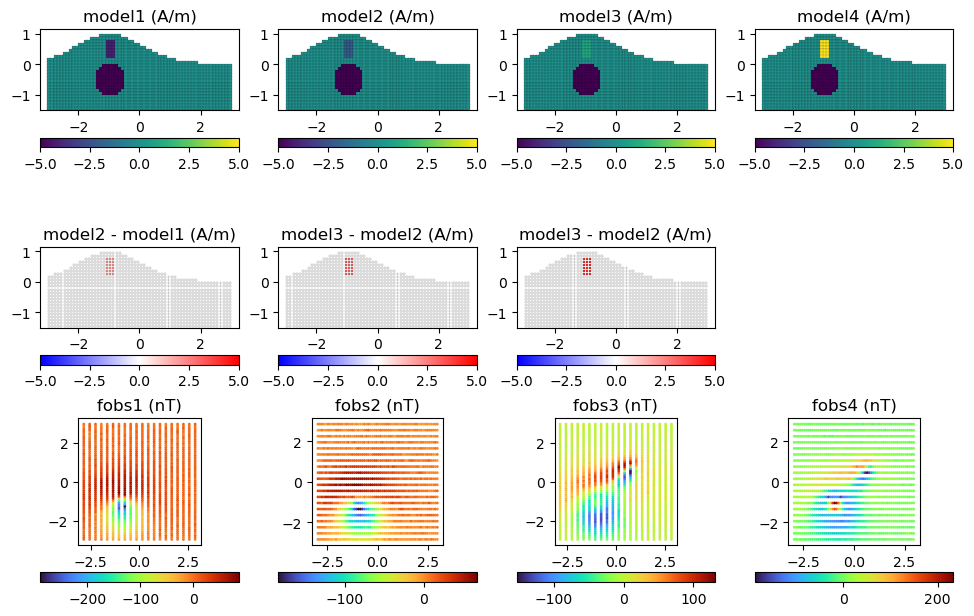

In [15]:
### Magnetization structure  ###

# Spherical demagnetized source  
zcenter = -0.5
a_rad = 0.5
b_rad = 0.5
c_rad = 0.5

# Lateral dike intrusion
# Direction vector (NE + 30° upward)
d = np.array([
    np.cos(np.deg2rad(10)) / np.sqrt(2),
    np.cos(np.deg2rad(10)) / np.sqrt(2),
    np.sin(np.deg2rad(10))
])  # Normalized

# Center
center = np.array([-0.95, -0.95, -0.2])

# Dike radius
dike_r = 0.1

# Vector from grid points to the dike reference point
dx = xx2 - center[0]
dy = yy2 - center[1]
dz = zz2 - center[2]

# Axial distance t (projection)
t = dx * d[0] + dy * d[1] + dz * d[2]

# Distance from the axis
px = center[0] + t * d[0]
py = center[1] + t * d[1]
pz = center[2] + t * d[2]

dist_axis = np.sqrt((xx2 - px)**2 + (yy2 - py)**2 + (zz2 - pz)**2)

# ------------------------------------------------------------ #
### Time1 ###
beta1 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta1[k] = -5

# Dike 1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta1[k] = -4

### Time2 ###
beta2 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta2[k] = -5
                
# Dike 1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta2[k] = -2
                
### Time3 ###
beta3 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta3[k] = -5

# Dike 1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta3[k] = 1

# Dike 2
L3 = 2.6 # Dike length
inside_dike = (dist_axis <= dike_r) & (t >= 0) & (t <= L3)
beta3.reshape(xx2.shape)[inside_dike] = -5

### Time4 ###
beta4 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta4[k] = -5

# Dike 1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] + - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta4[k] = 5

# Dike 2
L4 = 2.6 # Dike length
inside_dike = (dist_axis <= dike_r) & (t >= 0) & (t <= L4)
beta4.reshape(xx2.shape)[inside_dike] = -5

# ------------------------------------------------------------ #

# Compute magnetic anomalies
f1_row = K1.dot(beta1)
f2_row = K2.dot(beta2)
f3_row = K3.dot(beta3)
f4_row = K4.dot(beta4)

# Add Gaussian noise
np.random.seed(42)
noise1 = np.random.normal(loc=0, scale=5.0, size=len(f1_row)) # 5 nT
noise2 = np.random.normal(loc=0, scale=5.0, size=len(f2_row)) # 5 nT
noise3 = np.random.normal(loc=0, scale=5.0, size=len(f3_row)) # 5 nT
noise4 = np.random.normal(loc=0, scale=5.0, size=len(f4_row)) # 5 nT
fobs1 = f1_row + noise1
fobs2 = f2_row + noise2
fobs3 = f3_row + noise3
fobs4 = f4_row + noise4

bb1 = beta1.reshape(nz, ny, nx)
bb2 = beta2.reshape(nz, ny, nx)
bb3 = beta3.reshape(nz, ny, nx)
bb4 = beta4.reshape(nz, ny, nx)

<timed exec>:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.


CPU times: total: 33.1 s
Wall time: 49.5 s


Text(0.5, 1.0, 'NE–SW Cross-section (No Interpolation)')

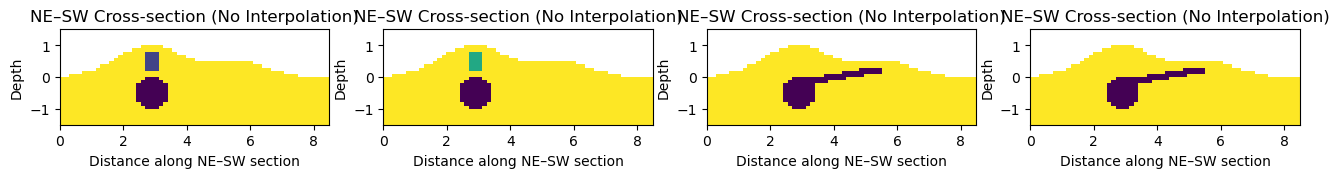

In [16]:
%%time
# Colormap
from matplotlib import cm
cmap = cm.get_cmap("gist_earth")
norm = Normalize(vmin = -100, vmax = 1100)

# Dashed line
# Start and end points
P0 = np.array([-3, -3])
P1 = np.array([3, 3])

# Direction vector and normalization
d = P1 - P0
d_norm = d / np.linalg.norm(d)

# Distance range
t1, t2 = 1.0, 7.0

# Generate points along the line segment
ts = np.linspace(t1, t2, 200)
points = P0 + np.outer(ts, d_norm)


# Visualization
fig = plt.figure(figsize = (14, 12.5))
plt.subplots_adjust(wspace=0.1, hspace=-0.3)

#--- Topography ---#

ax = fig.add_subplot(541)
p = ax.pcolor(X, Y, T*1e3, cmap = cmap)
p.set_clim(-100, 1100)

ax.plot(points[:, 0], points[:, 1], linestyle='--', color='white', linewidth=2)

ax.set_aspect("equal")
ax.set_xlim(-3, )
ax.set_ylim(-3, )
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%", 
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Topography (m)", fontsize = 12)


#--- Input model ---#

# Colormap
cmap = cm.get_cmap("RdYlBu")
norm = Normalize(vmin = -6, vmax = 6)

# T = T1
ax = fig.add_subplot(5,4,9)

# Cross-section (NE–SW)
for i in range(len(xgrd)):

    # 8 vertices of the voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE–SW section condition: y ≈ x ---
    # Voxel center
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the section (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on beta value
        beta_val = beta1[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (no interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%",
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T2
ax = fig.add_subplot(5,4,10)

# Cross-section (NE–SW)
for i in range(len(xgrd)):

    # 8 vertices of the voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE–SW section condition: y ≈ x ---
    # Voxel center
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the section (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on beta value
        beta_val = beta2[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (no interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%",
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T_3
ax = fig.add_subplot(5,4,11)

# Cross-section (NE–SW)
for i in range(len(xgrd)):

    # 8 vertices of the voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE–SW section condition: y ≈ x ---
    # Voxel center
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the section (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on beta value
        beta_val = beta3[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (no interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%", 
                 height="10%", 
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T_4 
ax = fig.add_subplot(5,4,12)

# Cross-section (NE–SW)
for i in range(len(xgrd)):

    # 8 vertices of the voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE–SW section condition: y ≈ x ---
    # Voxel center
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the section (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on beta value
        beta_val = beta4[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (no interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_4$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%",
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

### data ###

# T = T_1
ax = fig.add_subplot(5,4,17)
p = ax.scatter(xobs1, yobs1, c = fobs1, cmap = "turbo", s = 1)
#plt.colorbar(p)
p.set_clim(-350, 150)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -350, vmax = 150)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%",
                 height="10%", 
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_2
ax = fig.add_subplot(5,4,18)
p = ax.scatter(xobs2, yobs2, c = fobs2, cmap = "turbo", s = 1)
#plt.colorbar(p)
p.set_clim(-200, 100)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -200, vmax = 100)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%", 
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_3
ax = fig.add_subplot(5,4,19)
p = ax.scatter(xobs3, yobs3, c = fobs3, cmap = "turbo", s = 1)
#plt.colorbar(p)
p.set_clim(-200, 150)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# 
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -200, vmax = 150)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([]) 
cax = inset_axes(ax,
                 width="85%", 
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_4
ax = fig.add_subplot(5,4,20)
p = ax.scatter(xobs4, yobs4, c = fobs4, cmap = "turbo", s = 1)

#plt.colorbar(p)
p.set_clim(-200, 200)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -200, vmax = 200)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%", 
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

### Pick up cross points

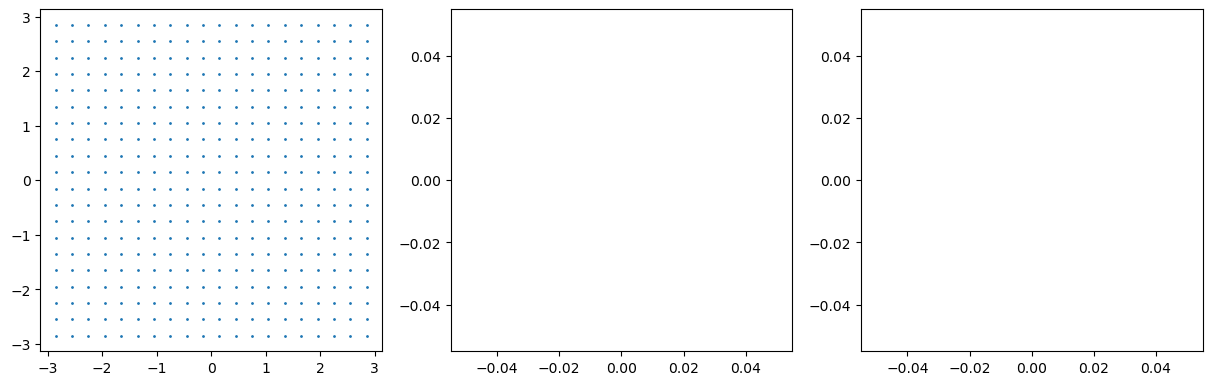

In [18]:
# diff  # T_2 - T_1
xobs_del12_all = []
yobs_del12_all = []
zobs_del12_all = []
fobs_del12_all = []

# search
for i in range(len(xobs1)):
    for j in range(len(xobs2)):
        
        if (np.abs(xobs1[i] - xobs2[j]) < 1e-3) & (np.abs(yobs1[i] - yobs2[j]) < 1e-3) & (np.abs(zobs1[i] - zobs2[j]) < 1e-3):

            # coordinate
            xobs_del12_all.append(xobs1[i])
            yobs_del12_all.append(yobs1[i])
            zobs_del12_all.append(zobs1[i])

            # data
            fobs_del12_all.append(fobs2[j] - fobs1[i])

# diff  # T_3 - T_2
xobs_del23_all = []
yobs_del23_all = []
zobs_del23_all = []
fobs_del23_all = []

# search
for i in range(len(xobs2)):
    for j in range(len(xobs3)):
        
        if (np.abs(xobs2[i] - xobs3[j]) < 1e-3) & (np.abs(yobs2[i] - yobs3[j]) < 1e-3) & (np.abs(zobs2[i] - zobs3[j]) < 1e-3):

            # coordinate
            xobs_del23_all.append(xobs2[i])
            yobs_del23_all.append(yobs2[i])
            zobs_del23_all.append(zobs2[i])

            # data
            fobs_del23_all.append(fobs3[j] - fobs2[i])
            
# diff  # T_4 - T_3
xobs_del34_all = []
yobs_del34_all = []
zobs_del34_all = []
fobs_del34_all = []

# search
for i in range(len(xobs3)):
    for j in range(len(xobs4)):
        
        if (np.abs(xobs3[i] - xobs4[j]) < 1e-3) & (np.abs(yobs3[i] - yobs4[j]) < 1e-3) & (np.abs(zobs3[i] - zobs4[j]) < 1e-3):

            # coordinate
            xobs_del34_all.append(xobs3[i])
            yobs_del34_all.append(yobs3[i])
            zobs_del34_all.append(zobs3[i])

            # data
            fobs_del34_all.append(fobs4[j] - fobs3[i])

# Visualization
fig = plt.figure(figsize = (15, 5))

ax1 = fig.add_subplot(131)
p = ax1.scatter(xobs_del12_all, yobs_del12_all, s = 1)
#plt.colorbar(p, orientation = "horizontal")
#p.set_clim(-5, 5)
ax1.set_aspect("equal")

ax2 = fig.add_subplot(132)
p = ax2.scatter(xobs_del23_all, yobs_del23_all, s = 1)
#plt.colorbar(p, orientation = "horizontal")
#p.set_clim(-15, 15)
ax2.set_aspect("equal")

ax3 = fig.add_subplot(133)
p = ax3.scatter(xobs_del34_all, yobs_del34_all, s = 1)
#plt.colorbar(p, orientation = "horizontal")
#p.set_clim(-20, 20)
ax3.set_aspect("equal")

In [19]:
%%time
# Compute the kernel matrix using parallel processing with threading
# Create unit vector
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# Number of threads (number of parallel workers)
n = 12

# Divide the computation range i = [0, nz] into n segments
p = np.linspace(0, nz-1, n).astype(int)
p[-1] += 1
print(p)

# Store return values from each thread in the ThreadPool
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs_del12_all, yobs_del12_all, zobs_del12_all, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# Retrieve results and stack them to construct the final kernel matrix
K_del12 = []
for res in results:
    Ki = res.result()
    if len(K_del12) == 0:
        K_del12 = Ki.copy()
    else:
        K_del12 = np.hstack((K_del12, Ki))

[ 0  2  5  7 10 13 15 18 21 23 26 30]
0
18000
36000
54000
65000
47000
83000
94000
76000
8000
26000
37000
55000
1000
19000
48000
66000
84000
95000
77000
38000
56000
9000
27000
49000
67000
85000
2000
20000
96000
78000
39000
57000
50000
86000
68000
10000
28000
97000
79000
3000
21000
40000
58000
51000
87000
69000
98000
11000
80000
29000
4000
22000
41000
59000
52000
88000
70000
99000
81000
12000
30000
5000
23000
42000
60000
53000
89000
71000
100000
82000
13000
31000
6000
43000
24000
61000
90000
72000
101000
14000
32000
44000
62000
7000
25000
91000
73000
102000
15000
33000
45000
63000
92000
74000
103000
16000
46000
34000
64000
93000
75000
104000
17000
35000
105000
106000
107000
CPU times: total: 1h 2min 2s
Wall time: 46min 52s


In [20]:
# Depth weighting
w_del12 = np.linalg.norm(K_del12, axis=0)
X_del12 = K_del12 / w_del12
XXT_del12 = X_del12.dot(X_del12.T)

((400, 108000),)

### Differentiall Inversion

In [21]:
# hyper-parameters
lams = np.power(10., np.arange(0.0, 2.6, 0.25))
print("lams = {}".format(lams))

# ratio of L1 norm and L2 norm
alpha_ = 0.9

lams = [  1.           1.77827941   3.16227766   5.62341325  10.
  17.7827941   31.6227766   56.23413252 100.         177.827941
 316.22776602]


In [25]:
%%time
params_all = []
betas_del12_all = []

for li in range(len(lams)):

    params_all.append(lams[li])
    
    l_1 = lams[li] * alpha_
    l_2 = lams[li] * (1. - alpha_)
    print("λ1 = {}, λ2 = {}".format(l_1, l_2))
    
    # インバージョン解析を実行
    model1 = L1L2(l_1, l_2, rho_=1.0, eta_=0.0, fit_intercept = False, eps_ADMM = 1.e-3)
    model1.algorithm(X_del12, fobs_del12_all, w_del12)
    beta_sim_del12 = model1.beta_ / w_del12

    betas_del12_all.append(beta_sim_del12)

# ndarry
params_all = np.array(params_all)
betas_del12_all = np.array(betas_del12_all)

λ1 = 0.9, λ2 = 0.09999999999999998
intercept = False
no-constrained
iter = 0, delta = 0.09296589722763318
103
λ1 = 1.6004514690350304, λ2 = 0.17782794100389224
intercept = False
no-constrained
iter = 0, delta = 0.09716614397132285
181
λ1 = 2.8460498941515415, λ2 = 0.3162277660168379
intercept = False
no-constrained
iter = 0, delta = 0.09785982537401779
323
λ1 = 5.061071926713142, λ2 = 0.562341325190349
intercept = False
no-constrained
iter = 0, delta = 0.09785982537401779
563
λ1 = 9.0, λ2 = 0.9999999999999998
intercept = False
no-constrained
iter = 0, delta = 0.09785982537401779
925
λ1 = 16.004514690350305, λ2 = 1.7782794100389225
intercept = False
no-constrained
iter = 0, delta = 0.09785982537401779
iter = 1000, delta = 0.0013027162751305598
1345
λ1 = 28.460498941515414, λ2 = 3.1622776601683786
intercept = False
no-constrained
iter = 0, delta = 0.09785982537401779
iter = 1000, delta = 0.0015936033379642198
1622
λ1 = 50.610719267131415, λ2 = 5.623413251903489
intercept = False
no-const

In [26]:
import pickle
with open('models/Params_case_2_2_differential.pickle', 'wb') as f:
    pickle.dump(params_all, f)
with open('models/Betas_del12_case_2_2_differential.pickle', 'wb') as f:
    pickle.dump(betas_del12_all, f)

In [27]:
# calc rss, pen
# T2 - T1
rss_temp_del12 = []
pen_temp_del12 = []
for i in range(len(lams)):
    rss_temp_del12.append(misfit(fobs_del12_all, K_del12, betas_del12_all[i]))
    pen_temp_del12.append(pen(betas_del12_all[i]*w_del12, alpha=0.9))

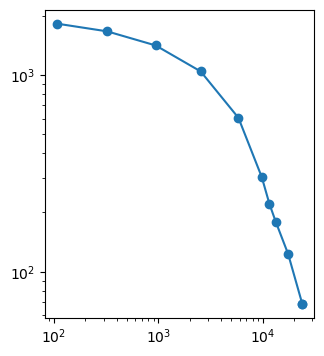

In [28]:
# L-curve
fig = plt.figure(figsize = (16, 4))

ax = fig.add_subplot(141)
ax.loglog(rss_temp_del12, pen_temp_del12, "o-")
#ax.plot(rss_temp_del12, pen_temp_del12, "o-")


C:\Users\ri710\AppData\Local\Temp\ipykernel_23876\2415805396.py:8: RuntimeWarning: invalid value encountered in divide
  curvature = np.abs(dif2_x * dif_y - dif_x * dif2_y) / (dif_x **2 + dif_y **2)**1.5


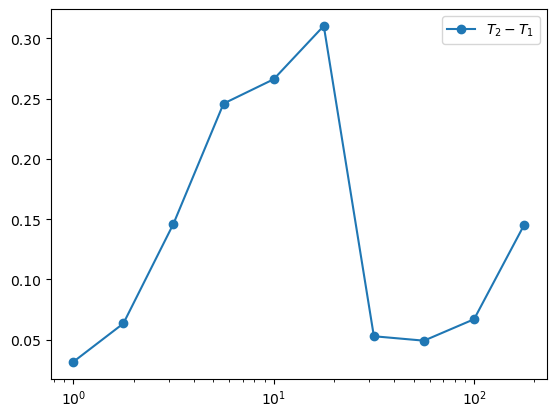

In [29]:
plt.semilogx(lams, calcCurvature2(np.log(rss_temp_del12), np.log(pen_temp_del12)), "o-", label = "$T_2 - T_1$")
plt.legend()